# TradeEnv Data Download & Preparation

**Before running the rest of the hackathon notebook:**

1. Run the **Data Download** cell below to fetch 5 months of NIFTY-50 data from yfinance
2. Save the CSV file to the repo
3. Commit and push the data file

This ensures the environment has real market data to work with.


In [21]:
import os
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path

# NIFTY-50 stock tickers (Yahoo Finance format: .NS suffix for Indian stocks)
NIFTY50_SYMBOLS = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "ITC.NS",
    "LT.NS", "KOTAKBANK.NS", "HINDUNILVR.NS", "AXISBANK.NS", "ASIANPAINT.NS", "BAJFINANCE.NS",
    "MARUTI.NS", "SUNPHARMA.NS", "TITAN.NS", "ULTRACEMCO.NS", "WIPRO.NS", "NTPC.NS", "POWERGRID.NS",
]

# Create data directory if it doesn't exist
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

print(f"Downloading 5 months of NIFTY-50 data for {len(NIFTY50_SYMBOLS)} symbols...")
print(f"Symbols: {', '.join(NIFTY50_SYMBOLS[:5])}...")

# Download data
raw = yf.download(
    tickers=NIFTY50_SYMBOLS,
    period="5mo",
    interval="1d",
    auto_adjust=True,
    progress=True,
    group_by="ticker",
    threads=False,
)

# Process and combine data
rows = []
for sym in NIFTY50_SYMBOLS:
    try:
        if isinstance(raw.columns, pd.MultiIndex):
            if sym not in raw.columns.get_level_values(0):
                continue
            sdf = raw[sym].copy()
        else:
            sdf = raw.copy()

        if sdf.empty:
            continue
        
        sdf = sdf.rename(columns={c: c.lower() for c in sdf.columns})
        req = ["open", "high", "low", "close", "volume"]
        if not set(req).issubset(set(sdf.columns)):
            continue

        sdf = sdf[req].dropna().copy()
        sdf["symbol"] = sym
        rows.append(sdf)
        print(f"  ✓ {sym}: {len(sdf)} rows")
    except Exception as e:
        print(f"  ✗ {sym}: {e}")

if not rows:
    print("ERROR: No data downloaded. Check your internet connection and symbol names.")
else:
    df = pd.concat(rows).reset_index().rename(columns={"Date": "date", "index": "date"})
    if "date" not in df.columns:
        df = df.rename(columns={df.columns[0]: "date"})

    df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

    # Compute technical indicators
    def _feat(group):
        g = group.copy()
        g["ema_fast"] = g["close"].ewm(span=5, adjust=False).mean()
        g["ema_slow"] = g["close"].ewm(span=14, adjust=False).mean()
        delta = g["close"].diff().fillna(0.0)
        up = delta.clip(lower=0.0)
        down = -delta.clip(upper=0.0)
        roll_up = up.rolling(14, min_periods=1).mean()
        roll_down = down.rolling(14, min_periods=1).mean()
        rs = roll_up / np.maximum(roll_down, 1e-9)
        g["rsi_14"] = 100.0 - (100.0 / (1.0 + rs))
        g["vwap"] = (g["close"] * g["volume"]).cumsum() / np.maximum(g["volume"].cumsum(), 1.0)
        return g

    df = df.groupby("symbol", group_keys=False).apply(_feat).reset_index(drop=True)

    # Save to CSV
    output_path = data_dir / "nifty50_market_data.csv"
    df.to_csv(output_path, index=False)
    print(f"\n✓ Saved {len(df)} rows to {output_path}")
    print(f"  Symbols: {df['symbol'].nunique()}")
    print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"\nNext: Commit this file to the repo:")
    print(f"  git add {output_path}")
    print(f"  git commit -m 'Add NIFTY50 market data'")
    print(f"  git push")


[                       0%                       ]

Symbols: RELIANCE.NS, TCS.NS, INFY.NS, HDFCBANK.NS, ICICIBANK.NS...


[*********************100%***********************]  20 of 20 completed

  ✓ RELIANCE.NS: 102 rows
  ✓ TCS.NS: 102 rows
  ✓ INFY.NS: 102 rows
  ✓ HDFCBANK.NS: 102 rows
  ✓ ICICIBANK.NS: 102 rows
  ✓ SBIN.NS: 102 rows
  ✓ ITC.NS: 102 rows
  ✓ LT.NS: 102 rows
  ✓ KOTAKBANK.NS: 102 rows
  ✓ HINDUNILVR.NS: 102 rows
  ✓ AXISBANK.NS: 102 rows
  ✓ ASIANPAINT.NS: 102 rows
  ✓ BAJFINANCE.NS: 102 rows
  ✓ MARUTI.NS: 102 rows
  ✓ SUNPHARMA.NS: 102 rows
  ✓ TITAN.NS: 102 rows
  ✓ ULTRACEMCO.NS: 102 rows
  ✓ WIPRO.NS: 102 rows
  ✓ NTPC.NS: 102 rows
  ✓ POWERGRID.NS: 102 rows

✓ Saved 2040 rows to ../data/nifty50_market_data.csv
  Symbols: 20
  Date range: 2025-11-10 to 2026-04-08

Next: Commit this file to the repo:
  git add ../data/nifty50_market_data.csv
  git commit -m 'Add NIFTY50 market data'
  git push



/var/folders/jb/2yhtg48x5zv4vdxrfxd3rjg80000gp/T/ipykernel_85511/2050502469.py:83: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("symbol", group_keys=False).apply(_feat).reset_index(drop=True)


# TradeEnv Hackathon Notebook

This notebook builds a minimal, professional baseline for bulk stock execution:
- Download 5 months of NIFTY data from yfinance
- Create a test-day execution simulator with max `k=10` trades/day
- Train a tiny deep-learning policy (2-layer MLP in NumPy)
- Compare policy vs random baseline on test days

In [22]:
import numpy as np
import pandas as pd
import yfinance as yf

SEED = 42
rng = np.random.default_rng(SEED)

NIFTY50 = [
    'RELIANCE.NS','TCS.NS','INFY.NS','HDFCBANK.NS','ICICIBANK.NS','SBIN.NS','ITC.NS',
    'LT.NS','KOTAKBANK.NS','HINDUNILVR.NS','AXISBANK.NS','ASIANPAINT.NS','BAJFINANCE.NS',
    'MARUTI.NS','SUNPHARMA.NS','TITAN.NS','ULTRACEMCO.NS','WIPRO.NS','NTPC.NS','POWERGRID.NS'
]

raw = yf.download(
    tickers=NIFTY50,
    period='5mo',
    interval='1d',
    auto_adjust=True,
    progress=False,
    group_by='ticker',
    threads=False,
)

frames = []
for sym in NIFTY50:
    if isinstance(raw.columns, pd.MultiIndex):
        if sym not in raw.columns.get_level_values(0):
            continue
        s = raw[sym].copy()
    else:
        s = raw.copy()
    if s.empty:
        continue
    s = s.rename(columns={c: c.lower() for c in s.columns})
    req = ['open', 'high', 'low', 'close', 'volume']
    if not set(req).issubset(s.columns):
        continue
    s = s[req].dropna().copy()
    s['symbol'] = sym
    frames.append(s)

df = pd.concat(frames).reset_index().rename(columns={'Date': 'date', 'index': 'date'})
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

def add_indicators(g):
    g = g.copy()
    g['ema_fast'] = g['close'].ewm(span=5, adjust=False).mean()
    g['ema_slow'] = g['close'].ewm(span=14, adjust=False).mean()
    d = g['close'].diff().fillna(0.0)
    up = d.clip(lower=0.0).rolling(14, min_periods=1).mean()
    dn = (-d.clip(upper=0.0)).rolling(14, min_periods=1).mean()
    rs = up / np.maximum(dn, 1e-9)
    g['rsi_14'] = 100 - (100 / (1 + rs))
    g['vwap_day_proxy'] = (g['close'] * g['volume']).cumsum() / np.maximum(g['volume'].cumsum(), 1.0)
    g['idx'] = np.arange(len(g))
    return g

df = df.groupby('symbol', group_keys=False).apply(add_indicators).reset_index(drop=True)
df = df[df['idx'] >= 14].reset_index(drop=True)

# --- Website-sourced fundamentals (Yahoo Finance) ---
def fetch_fundamentals(sym):
    # Values sourced from Yahoo Finance key statistics/financial data via yfinance
    defaults = {
        'pe_ratio': 20.0,
        'price_to_book': 3.0,
        'return_on_equity': 0.12,
        'debt_to_equity': 80.0,
        'profit_margin': 0.08,
        'revenue_growth': 0.10,
        'fundamental_quality_score': 0.50,
    }
    try:
        info = yf.Ticker(sym).info
        pe = float(info.get('trailingPE') or defaults['pe_ratio'])
        pb = float(info.get('priceToBook') or defaults['price_to_book'])
        roe = float(info.get('returnOnEquity') or defaults['return_on_equity'])
        dte = float(info.get('debtToEquity') or defaults['debt_to_equity'])
        pm = float(info.get('profitMargins') or defaults['profit_margin'])
        rg = float(info.get('revenueGrowth') or defaults['revenue_growth'])

        quality = (
            0.20 * np.clip(1.0 - pe / 45.0, 0.0, 1.0)
            + 0.15 * np.clip(1.0 - pb / 8.0, 0.0, 1.0)
            + 0.25 * np.clip((roe + 0.1) / 0.5, 0.0, 1.0)
            + 0.15 * np.clip(1.0 - dte / 250.0, 0.0, 1.0)
            + 0.15 * np.clip((pm + 0.05) / 0.35, 0.0, 1.0)
            + 0.10 * np.clip((rg + 0.1) / 0.6, 0.0, 1.0)
        )
        return {
            'pe_ratio': max(pe, 0.0),
            'price_to_book': max(pb, 0.0),
            'return_on_equity': roe,
            'debt_to_equity': max(dte, 0.0),
            'profit_margin': pm,
            'revenue_growth': rg,
            'fundamental_quality_score': float(np.clip(quality, 0.0, 1.0)),
        }
    except Exception:
        return defaults

fund_rows = []
for sym in sorted(df['symbol'].unique()):
    row = fetch_fundamentals(sym)
    row['symbol'] = sym
    fund_rows.append(row)

fund_df = pd.DataFrame(fund_rows)
df = df.merge(fund_df, on='symbol', how='left')

print('rows:', len(df), 'symbols:', df['symbol'].nunique())
print('fundamental columns:', [c for c in ['pe_ratio','price_to_book','return_on_equity','debt_to_equity','profit_margin','revenue_growth','fundamental_quality_score'] if c in df.columns])
df.head()

/var/folders/jb/2yhtg48x5zv4vdxrfxd3rjg80000gp/T/ipykernel_85511/4115251770.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('symbol', group_keys=False).apply(add_indicators).reset_index(drop=True)


rows: 1760 symbols: 20
fundamental columns: ['pe_ratio', 'price_to_book', 'return_on_equity', 'debt_to_equity', 'profit_margin', 'revenue_growth', 'fundamental_quality_score']


,date,open,high,low,close,volume,symbol,ema_fast,ema_slow,rsi_14,vwap_day_proxy,idx,pe_ratio,price_to_book,return_on_equity,debt_to_equity,profit_margin,revenue_growth,fundamental_quality_score
0,2025-11-28,2880.000000,2889.899902,2855.800049,2874.399902,748446,ASIANPAINT.NS,2875.094779,2840.241751,80.234102,2850.700727,14,57.04574,11.169619,0.12,17.609,0.11098,0.037,0.341259
1,2025-12-01,2877.699951,2887.500000,2848.000000,2867.600098,499153,ASIANPAINT.NS,2872.596552,2843.889530,78.432343,2850.986851,15,57.04574,11.169619,0.12,17.609,0.11098,0.037,0.341259
2,2025-12-02,2867.000000,2962.000000,2861.199951,2954.399902,2102147,ASIANPAINT.NS,2899.864335,2858.624246,76.860727,2857.869833,16,57.04574,11.169619,0.12,17.609,0.11098,0.037,0.341259
3,2025-12-03,2969.000000,2969.199951,2932.600098,2953.500000,1252456,ASIANPAINT.NS,2917.742890,2871.274347,66.161574,2861.517425,17,57.04574,11.169619,0.12,17.609,0.11098,0.037,0.341259
4,2025-12-04,2950.000000,2985.699951,2934.000000,2957.199951,1466098,ASIANPAINT.NS,2930.895244,2882.731094,62.582127,2865.606961,18,57.04574,11.169619,0.12,17.609,0.11098,0.037,0.341259


In [23]:
def synthetic_path(row, n=10):
    x = np.array([0.0, 0.35, 0.7, 1.0])
    y = np.array([row.open, row.low, row.high, row.close], dtype=float)
    return np.interp(np.linspace(0, 1, n), x, y)

def build_dataset(frame):
    feats, labels = [], []
    for r in frame.itertuples(index=False):
        path = synthetic_path(r, n=10)
        spread = max(r.high - r.low, 1e-6)
        for t, px in enumerate(path):
            progress = t / 9
            f = [
                (px - r.vwap_day_proxy) / max(r.vwap_day_proxy, 1e-6),
                (r.ema_fast - r.ema_slow) / max(r.ema_slow, 1e-6),
                (r.rsi_14 - 50.0) / 50.0,
                (px - r.low) / spread,
                progress,
                np.clip((r.pe_ratio - 20.0) / 25.0, -1.0, 1.0),
                np.clip((r.price_to_book - 3.0) / 5.0, -1.0, 1.0),
                np.clip((r.return_on_equity - 0.12) / 0.3, -1.0, 1.0),
                np.clip((r.debt_to_equity - 80.0) / 170.0, -1.0, 1.0),
                np.clip((r.profit_margin - 0.08) / 0.2, -1.0, 1.0),
                np.clip((r.revenue_growth - 0.10) / 0.4, -1.0, 1.0),
                np.clip((r.fundamental_quality_score - 0.5) / 0.5, -1.0, 1.0),
            ]
            # Fundamental-aware teacher signal: cheap intraday + stronger fundamentals => larger buy
            price_position = (px - r.low) / spread  # 0=low, 1=high
            base = max(0.0, 1.0 - 1.5 * price_position)
            fundamentals_boost = 0.75 + 0.5 * np.clip(r.fundamental_quality_score, 0.0, 1.0)
            y = float(np.clip(base * fundamentals_boost, 0.0, 1.0))
            feats.append(f)
            labels.append([y])
    return np.array(feats, dtype=np.float32), np.array(labels, dtype=np.float32)

split_date = df['date'].quantile(0.75)
train_df = df[df['date'] <= split_date].copy()
test_df = df[df['date'] > split_date].copy()

X_train, y_train = build_dataset(train_df)
X_test, y_test = build_dataset(test_df)
print(f"Training set: {X_train.shape[0]} samples, label mean={y_train.mean():.3f}")
print(f"Test set: {X_test.shape[0]} samples, label mean={y_test.mean():.3f}")
print(f"Feature dimension (now includes fundamentals): {X_train.shape[1]}")
X_train.shape, X_test.shape


Training set: 13200 samples, label mean=0.372
Test set: 4400 samples, label mean=0.365
Feature dimension (now includes fundamentals): 12


((13200, 12), (4400, 12))

In [24]:
# Tiny DL policy: 2-layer MLP in NumPy with cross-entropy loss (better for classification)
d_in, d_h = X_train.shape[1], 32  # increased hidden units
W1 = rng.normal(0, np.sqrt(2.0 / d_in), size=(d_in, d_h)).astype(np.float32)  # He initialization
b1 = np.zeros((1, d_h), dtype=np.float32)
W2 = rng.normal(0, np.sqrt(1.0 / d_h), size=(d_h, 1)).astype(np.float32)
b2 = np.zeros((1, 1), dtype=np.float32)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))  # clip to prevent overflow

lr = 0.1  # increased learning rate for cross-entropy
for epoch in range(500):  # increased epochs
    z1 = X_train @ W1 + b1
    h1 = np.tanh(z1)
    z2 = h1 @ W2 + b2
    yhat = sigmoid(z2)
    
    # Binary cross-entropy loss (much better than MSE for sigmoid outputs)
    eps = 1e-7
    yhat_clipped = np.clip(yhat, eps, 1 - eps)
    loss = -np.mean(y_train * np.log(yhat_clipped) + (1 - y_train) * np.log(1 - yhat_clipped))
    
    # Backprop with cross-entropy (simpler gradient: just sigmoid error)
    dz2 = (yhat - y_train) / len(X_train)
    dW2 = h1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)
    
    dh1 = dz2 @ W2.T
    dz1 = dh1 * (1 - np.tanh(z1) ** 2)
    dW1 = X_train.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)
    
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1
    
    if epoch % 100 == 0:
        print(f'epoch={epoch:03d} loss={loss:.6f}')

def policy_fraction(x):
    h = np.tanh(x @ W1 + b1)
    return float(sigmoid(h @ W2 + b2).squeeze())


epoch=000 loss=0.734437
epoch=100 loss=0.423505
epoch=200 loss=0.347069
epoch=300 loss=0.318732
epoch=400 loss=0.308366


In [25]:
def run_day(row, mode='dl', target_qty=1000, k=10):
    path = synthetic_path(row, n=10)
    remaining = target_qty
    trades = 0
    notional = 0.0

    for t, px in enumerate(path):
        if remaining <= 0:
            break
        f = np.array([[
            (px - row.vwap_day_proxy) / max(row.vwap_day_proxy, 1e-6),
            (row.ema_fast - row.ema_slow) / max(row.ema_slow, 1e-6),
            (row.rsi_14 - 50.0) / 50.0,
            (px - row.low) / max(row.high - row.low, 1e-6),
            t / 9.0,
        ]], dtype=np.float32)

        if mode == 'dl':
            frac = policy_fraction(f)
        else:
            frac = rng.uniform(0, 1)

        if trades < k:
            q = int(min(remaining, max(0, frac * (target_qty / k))))
            if q > 0:
                trades += 1
                notional += q * px
                remaining -= q

    if remaining > 0:  # forced terminal fill
        notional += remaining * path[-1]
        remaining = 0

    avg_buy = notional / target_qty
    # score in [0,1]: lower avg buy is better
    score = (row.high - avg_buy) / max(row.high - row.low, 1e-6)
    score = float(np.clip(score, 0.0, 1.0))
    return avg_buy, score, trades

rows = []
for r in test_df.itertuples(index=False):
    dl_buy, dl_score, dl_trades = run_day(r, mode='dl', k=10)
    rd_buy, rd_score, rd_trades = run_day(r, mode='random', k=10)
    rows.append({
        'symbol': r.symbol, 'date': r.date,
        'dl_avg_buy': dl_buy, 'rand_avg_buy': rd_buy,
        'dl_score': dl_score, 'rand_score': rd_score,
        'dl_trades': dl_trades, 'rand_trades': rd_trades,
    })

res = pd.DataFrame(rows)
summary = pd.DataFrame({
    'metric': ['mean_score', 'median_score', 'mean_avg_buy', 'mean_trades'],
    'DL_policy': [res.dl_score.mean(), res.dl_score.median(), res.dl_avg_buy.mean(), res.dl_trades.mean()],
    'Random': [res.rand_score.mean(), res.rand_score.median(), res.rand_avg_buy.mean(), res.rand_trades.mean()],
})
summary

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 12 is different from 5)

In [ ]:
print('DL beats random on score:', (res.dl_score.mean() > res.rand_score.mean()))
display(res.head(10))
display(summary)

DL beats random on score: True


,symbol,date,dl_avg_buy,rand_avg_buy,dl_score,rand_score,dl_trades,rand_trades
0,ASIANPAINT.NS,2026-03-05,2281.461599,2286.717354,0.531844,0.443215,9,10
1,ASIANPAINT.NS,2026-03-06,2271.176128,2275.366746,0.677561,0.600243,9,10
2,ASIANPAINT.NS,2026-03-09,2208.022560,2209.759009,0.326075,0.300312,8,10
3,ASIANPAINT.NS,2026-03-10,2268.770871,2273.782176,0.679051,0.585382,9,10
4,ASIANPAINT.NS,2026-03-11,2235.274561,2245.221693,0.877966,0.747083,9,10
5,ASIANPAINT.NS,2026-03-12,2214.988676,2221.371494,0.713932,0.583404,9,10
6,ASIANPAINT.NS,2026-03-13,2196.834492,2198.513772,0.769882,0.713341,10,10
7,ASIANPAINT.NS,2026-03-16,2202.816891,2209.009734,0.474064,0.356553,8,10
8,ASIANPAINT.NS,2026-03-17,2229.972144,2236.102663,0.711689,0.573303,9,10
9,ASIANPAINT.NS,2026-03-18,2249.953466,2257.169837,0.489151,0.316510,8,10


,metric,DL_policy,Random
0,mean_score,0.617193,0.507346
1,median_score,0.625927,0.522775
2,mean_avg_buy,2485.705591,2493.954439
3,mean_trades,8.365909,9.886364


## Visual diagnostics: policy quality, trade efficiency, and symbol-level performance

This section adds richer plots to analyze where the DL policy wins/loses:

- score distribution (DL vs Random)
- score uplift by symbol
- trade-count efficiency
- score vs average buy relationship

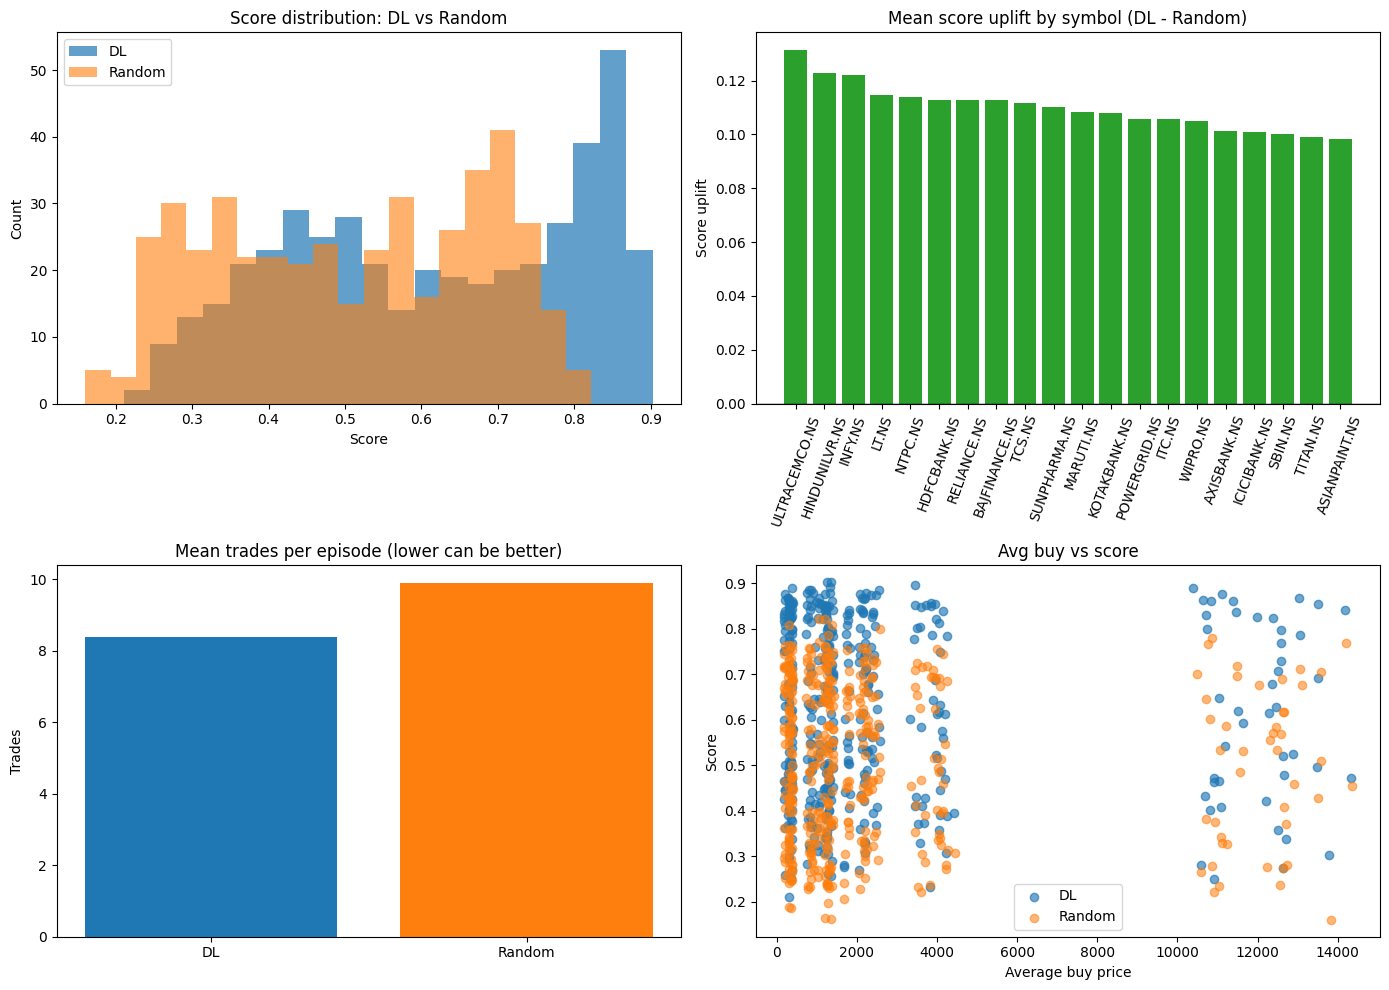

Top 5 symbols by DL uplift:


,symbol,score_uplift
18,ULTRACEMCO.NS,0.131355
4,HINDUNILVR.NS,0.122701
6,INFY.NS,0.122046
9,LT.NS,0.114704
11,NTPC.NS,0.114067


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = res.copy()
plot_df['score_uplift'] = plot_df['dl_score'] - plot_df['rand_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Score distribution
axes[0, 0].hist(plot_df['dl_score'], bins=20, alpha=0.7, label='DL', color='tab:blue')
axes[0, 0].hist(plot_df['rand_score'], bins=20, alpha=0.6, label='Random', color='tab:orange')
axes[0, 0].set_title('Score distribution: DL vs Random')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# 2) Uplift by symbol
uplift_by_symbol = plot_df.groupby('symbol', as_index=False)['score_uplift'].mean().sort_values('score_uplift', ascending=False)
axes[0, 1].bar(uplift_by_symbol['symbol'], uplift_by_symbol['score_uplift'], color='tab:green')
axes[0, 1].axhline(0.0, color='black', linewidth=1)
axes[0, 1].set_title('Mean score uplift by symbol (DL - Random)')
axes[0, 1].set_ylabel('Score uplift')
axes[0, 1].tick_params(axis='x', rotation=70)

# 3) Trade efficiency
trade_eff = pd.DataFrame({
    'policy': ['DL', 'Random'],
    'mean_trades': [plot_df['dl_trades'].mean(), plot_df['rand_trades'].mean()],
})
axes[1, 0].bar(trade_eff['policy'], trade_eff['mean_trades'], color=['tab:blue', 'tab:orange'])
axes[1, 0].set_title('Mean trades per episode (lower can be better)')
axes[1, 0].set_ylabel('Trades')

# 4) Score vs average buy
axes[1, 1].scatter(plot_df['dl_avg_buy'], plot_df['dl_score'], alpha=0.65, color='tab:blue', label='DL')
axes[1, 1].scatter(plot_df['rand_avg_buy'], plot_df['rand_score'], alpha=0.55, color='tab:orange', label='Random')
axes[1, 1].set_title('Avg buy vs score')
axes[1, 1].set_xlabel('Average buy price')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print('Top 5 symbols by DL uplift:')
display(uplift_by_symbol.head(5))